# DSN AI Bootcamp Qualification Hackathon — Product-Store Sales Prediction

**Task:** Predict `total_sales` for each row in `test.csv` (regression, evaluated by RMSE).

**Approach:** Understand → Analyse → Model → Predict → Communicate. This notebook covers cleaning, imputation, encoding, a multicollinearity check, a PCA experiment, feature engineering, target transformation, outlier analysis, regularization, cross-validation, hyperparameter tuning, and an ensemble spanning multiple model families (linear, bagged trees, SVM, and two GBM implementations), combined via a validated stacking meta-model.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor
import lightgbm as lgb
from catboost import CatBoostRegressor

pd.set_option('display.max_columns', None)


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 90


## 1. Load and Explore

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')
print("Train:", train.shape, " Test:", test.shape)
train.head()


Train: (6818, 13)  Test: (1705, 12)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [4]:
test.head()


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format
0,row_00009,PRD-2WLNC8,8.628,Low Fat,0.0167,household,190.72,STORE-HL7,23,Medium,Tier_3,Superstore
1,row_00015,PRD-LV9PLM,6.993,Low Fat,0.0579,Health and Hygiene,261.07,STORE-9RG,28,Small,Tier_2,Standard Supermarket
2,row_00019,PRD-ET6ZI7,NaN,Low Fat,0.1262,FRUITS AND VEGETABLES,112.50,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket
3,row_00020,PRD-6RX35U,14.034,Regular,0.0761,frozen foods,200.71,STORE-DKU,30,NaN,Tier_2,Standard Supermarket
4,row_00023,PRD-I4J38V,13.063,Low Fat,0.0650,Frozen Foods,150.59,STORE-89Z,33,Medium,Tier_1,Standard Supermarket


In [5]:
print("Missing values (train):\n", train.isnull().sum())
print("\nMissing values (test):\n", test.isnull().sum())
print("\nTarget stats:\n", train['total_sales'].describe())


Missing values (train):
 id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

Missing values (test):
 id                       0
product_code             0
product_weight_kg      306
fat_content              0
shelf_visibility         0
product_category         0
product_price            0
store_code               0
store_age_years          0
store_size             491
store_location_tier      0
store_format             0
dtype: int64

Target stats:
 count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
25%        834.792500
50%       1790.890000
75%       3092.587500
max      12996.820000
Name: total_sales, dtype: float64


**Key findings:**
- `product_weight_kg` and `store_size` have substantial missing values.
- `total_sales` is right-skewed (mean 2,175, std 1,698, range ~33-13,000).
- `store_code`: only 10 stores, fully shared between train/test — a strong low-cardinality feature.
- `product_category`/`fat_content` have inconsistent text casing.
- `shelf_visibility` has 422 rows equal to exactly 0, unrealistic for a product on a shelf — likely a missing-value placeholder.


## 1b. Exploratory Visualizations

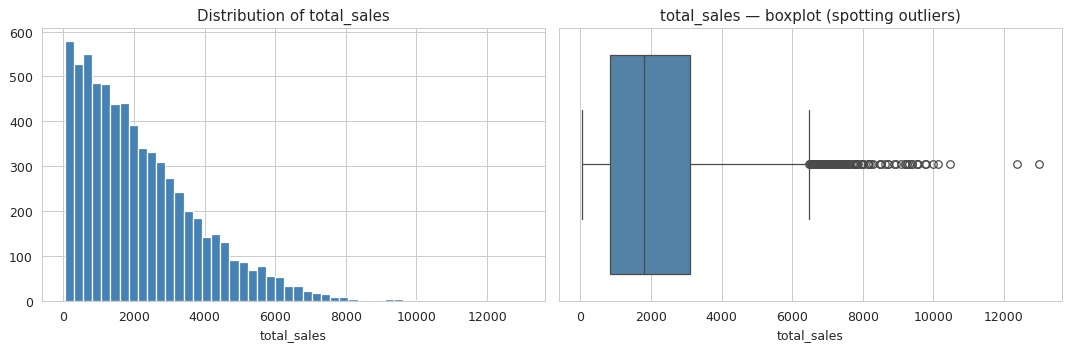

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train['total_sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of total_sales')
axes[0].set_xlabel('total_sales')
sns.boxplot(x=train['total_sales'], ax=axes[1], color='steelblue')
axes[1].set_title('total_sales — boxplot (spotting outliers)')
plt.tight_layout()
plt.savefig('eda_target_dist.png', dpi=90)
plt.show()


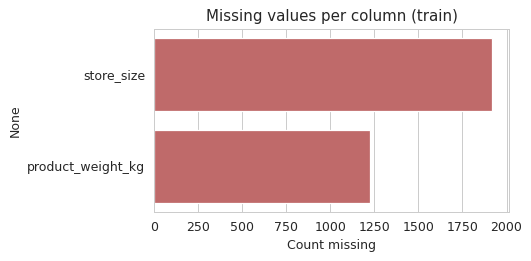

In [7]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
plt.figure(figsize=(6, 3))
sns.barplot(x=missing.values, y=missing.index, color='indianred')
plt.title('Missing values per column (train)')
plt.xlabel('Count missing')
plt.tight_layout()
plt.savefig('eda_missing.png', dpi=90)
plt.show()


/tmp/ipykernel_120/1740176600.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=store_sales.values, y=store_sales.index, palette='viridis')


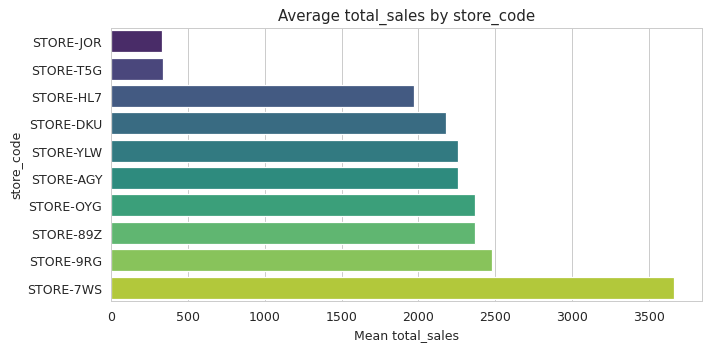

In [8]:
store_sales = train.groupby('store_code')['total_sales'].mean().sort_values()
plt.figure(figsize=(8, 4))
sns.barplot(x=store_sales.values, y=store_sales.index, palette='viridis')
plt.title('Average total_sales by store_code')
plt.xlabel('Mean total_sales')
plt.tight_layout()
plt.savefig('eda_store_sales.png', dpi=90)
plt.show()


Store identity alone explains a large share of the variance — this is the single most important feature discovered during EDA, and it's what motivated giving `store_code` its own target encoding rather than relying on one-hot alone.

/tmp/ipykernel_120/2877121579.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_sales.values, y=cat_sales.index, palette='mako')


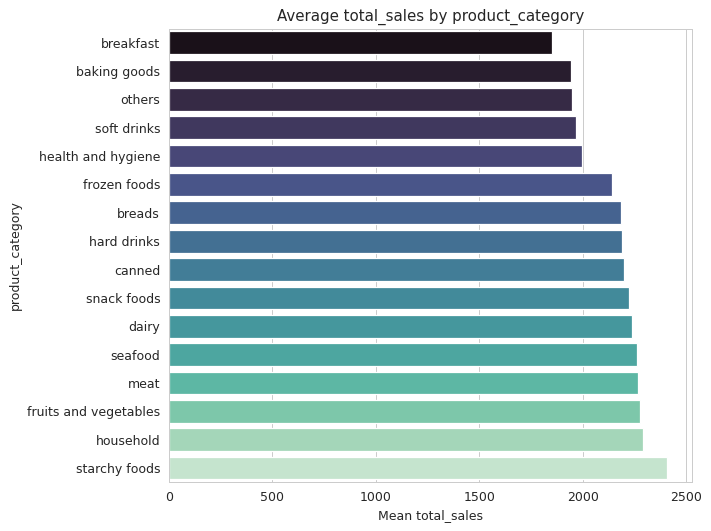

In [9]:
cat_sales = train.assign(product_category=train['product_category'].str.lower()).groupby('product_category')['total_sales'].mean().sort_values()
plt.figure(figsize=(8, 6))
sns.barplot(x=cat_sales.values, y=cat_sales.index, palette='mako')
plt.title('Average total_sales by product_category')
plt.xlabel('Mean total_sales')
plt.tight_layout()
plt.savefig('eda_category_sales.png', dpi=90)
plt.show()


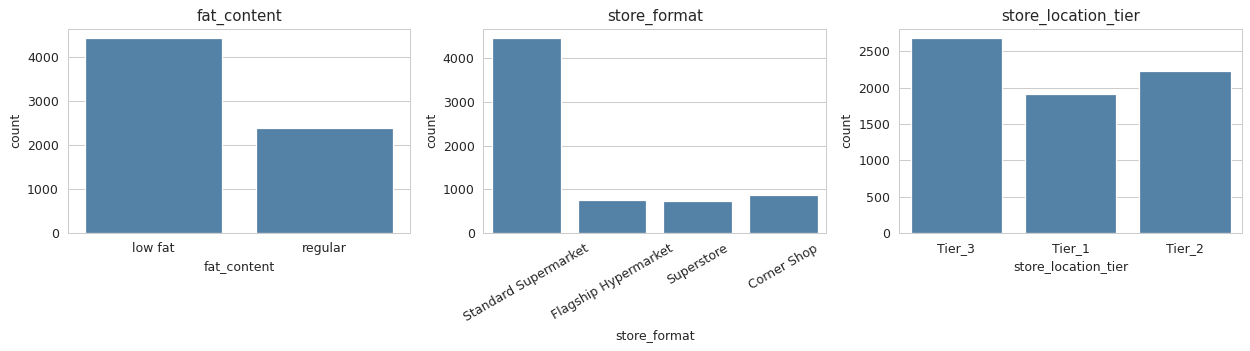

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.countplot(x=train['fat_content'].str.lower(), ax=axes[0], color='steelblue')
axes[0].set_title('fat_content')
sns.countplot(x=train['store_format'], ax=axes[1], color='steelblue')
axes[1].set_title('store_format')
axes[1].tick_params(axis='x', rotation=30)
sns.countplot(x=train['store_location_tier'], ax=axes[2], color='steelblue')
axes[2].set_title('store_location_tier')
plt.tight_layout()
plt.savefig('eda_categoricals.png', dpi=90)
plt.show()


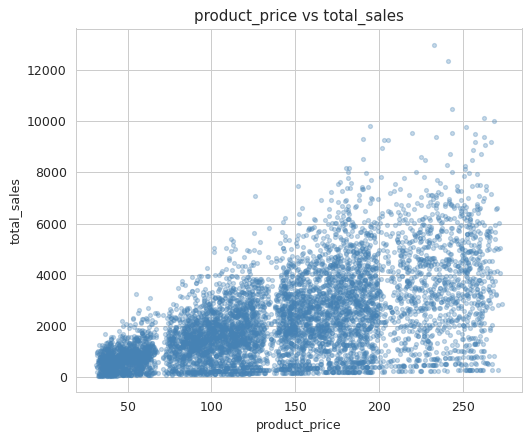

In [11]:
plt.figure(figsize=(6, 5))
plt.scatter(train['product_price'], train['total_sales'], alpha=0.3, s=10, color='steelblue')
plt.xlabel('product_price'); plt.ylabel('total_sales')
plt.title('product_price vs total_sales')
plt.tight_layout()
plt.savefig('eda_price_vs_sales.png', dpi=90)
plt.show()


`product_price` shows a clear positive relationship with `total_sales`, confirmed later by feature importance — it's one of the two strongest predictors alongside store identity.

## 2. Outlier Analysis

In [12]:
q1, q3 = np.percentile(train['total_sales'], [25, 75])
iqr = q3 - q1
outlier_mask = (train['total_sales'] < q1 - 1.5*iqr) | (train['total_sales'] > q3 + 1.5*iqr)
print(f"Target outliers by IQR rule: {outlier_mask.sum()} / {len(train)} ({outlier_mask.mean()*100:.1f}%)")


Target outliers by IQR rule: 144 / 6818 (2.1%)


**Decision:** these aren't measurement errors — they're naturally high-selling product/store combinations (a Flagship Hypermarket selling a popular item will legitimately have high sales). Deleting them would throw away real signal. Instead, a **log1p transform on the target** reduces the influence of the right skew without discarding any rows — addressed formally in Section 5.

## 3. Cleaning and Imputation

In [13]:
TARGET = 'total_sales'
n_train = len(train)
all_df = pd.concat([train.drop(columns=[TARGET]), test], axis=0, ignore_index=True)

# Normalize inconsistent text casing
all_df['product_category'] = all_df['product_category'].str.strip().str.lower()
all_df['fat_content'] = all_df['fat_content'].str.strip().str.lower()
all_df['fat_content'] = all_df['fat_content'].replace({'low fat': 'low_fat', 'lf': 'low_fat', 'regular': 'regular'})

# shelf_visibility == 0 treated as missing, imputed with category mean
all_df.loc[all_df['shelf_visibility'] == 0, 'shelf_visibility'] = np.nan
all_df['shelf_visibility'] = all_df['shelf_visibility'].fillna(
    all_df.groupby('product_category')['shelf_visibility'].transform('mean'))

# product_weight_kg: same product should weigh the same everywhere -> impute by product, fall back to category
all_df['product_weight_kg'] = all_df['product_weight_kg'].fillna(
    all_df.groupby('product_code')['product_weight_kg'].transform('mean'))
all_df['product_weight_kg'] = all_df['product_weight_kg'].fillna(
    all_df.groupby('product_category')['product_weight_kg'].transform('mean'))

# store_size: each store has exactly one size -> map from other rows of the same store
store_size_map = all_df.dropna(subset=['store_size']).drop_duplicates('store_code').set_index('store_code')['store_size']
all_df['store_size'] = all_df['store_code'].map(store_size_map).fillna('Unknown')

print("Remaining missing values:", all_df.isnull().sum().sum())


Remaining missing values: 0


This is deliberately more structure-aware than a generic median/mode fill: weight is borrowed from the same product first, and store size is borrowed from the same store, since both are properties that shouldn't vary within their group.

## 4. Feature Engineering

In [14]:
all_df['price_per_kg'] = all_df['product_price'] / all_df['product_weight_kg'].replace(0, np.nan)
all_df['price_rank_in_category'] = all_df.groupby('product_category')['product_price'].rank(pct=True)
all_df['product_count_in_train'] = all_df['product_code'].map(train['product_code'].value_counts()).fillna(0)


## 5. Target Transformation

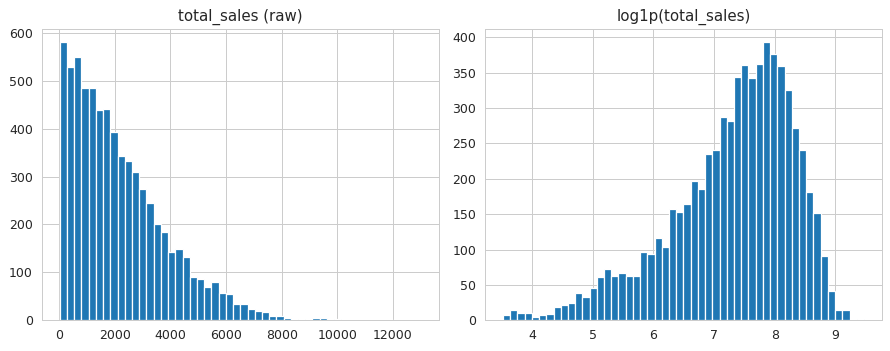

Raw skew: 1.154  Log skew: -0.895


In [15]:
y = train[TARGET].values
y_log = np.log1p(y)
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].hist(y, bins=50); axes[0].set_title('total_sales (raw)')
axes[1].hist(y_log, bins=50); axes[1].set_title('log1p(total_sales)')
plt.tight_layout(); plt.savefig('target_transform.png', dpi=80)
plt.show()
print("Raw skew:", pd.Series(y).skew().round(3), " Log skew:", pd.Series(y_log).skew().round(3))


`log1p` visibly reduces the right skew (confirmed by the skewness numbers dropping toward 0), which is why every model below is trained on `y_log` and predictions are converted back with `expm1`.

## 6. Encoding

Two different encoding strategies for two different model families:
- **Tree models (LightGBM, CatBoost)**: native categorical handling, kept as `category` dtype.
- **Linear/SVM models**: one-hot encoding for low-cardinality categoricals, and **out-of-fold target encoding** for high-cardinality ones (`store_code`, `product_category`, `product_code`, etc.) — computed only from other folds' data to avoid leaking the target into the encoding.


In [16]:
GLOBAL_MEAN = y.mean()
SMOOTHING = 15  # shrinks small-count categories toward the global mean

def smoothed_means(df_tr, col, target):
    agg = df_tr.groupby(col)[target].agg(['mean', 'count'])
    return (agg['mean'] * agg['count'] + GLOBAL_MEAN * SMOOTHING) / (agg['count'] + SMOOTHING)

X = all_df.iloc[:n_train].reset_index(drop=True).copy()
X_test = all_df.iloc[n_train:].reset_index(drop=True).copy()

te_cols = ['store_code', 'product_category', 'product_code', 'store_format', 'store_location_tier']
kf_te = KFold(n_splits=5, shuffle=True, random_state=1)
for col in te_cols:
    X[f'{col}_te'] = np.nan
    tmp = X.copy(); tmp[TARGET] = y
    for tr_idx, val_idx in kf_te.split(X):
        means = smoothed_means(tmp.iloc[tr_idx], col, TARGET)
        X.loc[val_idx, f'{col}_te'] = X.loc[val_idx, col].map(means).fillna(GLOBAL_MEAN)
    full_means = smoothed_means(tmp, col, TARGET)
    X_test[f'{col}_te'] = X_test[col].map(full_means).fillna(GLOBAL_MEAN)

cat_cols_raw = ['product_code', 'fat_content', 'product_category', 'store_code',
                'store_size', 'store_location_tier', 'store_format']

# Tree feature set
X_tree = X.copy(); X_test_tree = X_test.copy()
for c in cat_cols_raw:
    X_tree[c] = X_tree[c].astype('category')
    X_test_tree[c] = X_test_tree[c].astype('category')
tree_feature_cols = [c for c in X_tree.columns if c not in ['id']]

# Linear/SVM feature set
low_card_cols = ['fat_content', 'store_size', 'store_location_tier', 'store_format']
numeric_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years',
                'price_per_kg', 'price_rank_in_category', 'product_count_in_train',
                'store_code_te', 'product_category_te', 'product_code_te', 'store_format_te', 'store_location_tier_te']

X_lin = pd.get_dummies(X[low_card_cols + numeric_cols], columns=low_card_cols, drop_first=True)
X_test_lin = pd.get_dummies(X_test[low_card_cols + numeric_cols], columns=low_card_cols, drop_first=True)
X_test_lin = X_test_lin.reindex(columns=X_lin.columns, fill_value=0)
X_lin = X_lin.fillna(X_lin.median())
X_test_lin = X_test_lin.fillna(X_lin.median())
print("Linear feature set shape:", X_lin.shape)


Linear feature set shape: (6818, 21)


## 7. Multicollinearity Check

In [17]:
corr = X_lin[numeric_cols].corr()
X_vif_const = X_lin[numeric_cols].assign(const=1)
vif_data = pd.DataFrame({
    'feature': numeric_cols,
    'VIF': [variance_inflation_factor(X_vif_const.values, i) for i in range(len(numeric_cols))]
})
print(vif_data.sort_values('VIF', ascending=False))


                   feature         VIF
10         store_format_te  103.304326
7            store_code_te  102.662418
2            product_price   44.814756
5   price_rank_in_category   41.026306
4             price_per_kg    7.218127
0        product_weight_kg    3.873310
9          product_code_te    2.372223
8      product_category_te    1.368740
3          store_age_years    1.188840
11  store_location_tier_te    1.182293
1         shelf_visibility    1.087111
6   product_count_in_train    1.003546


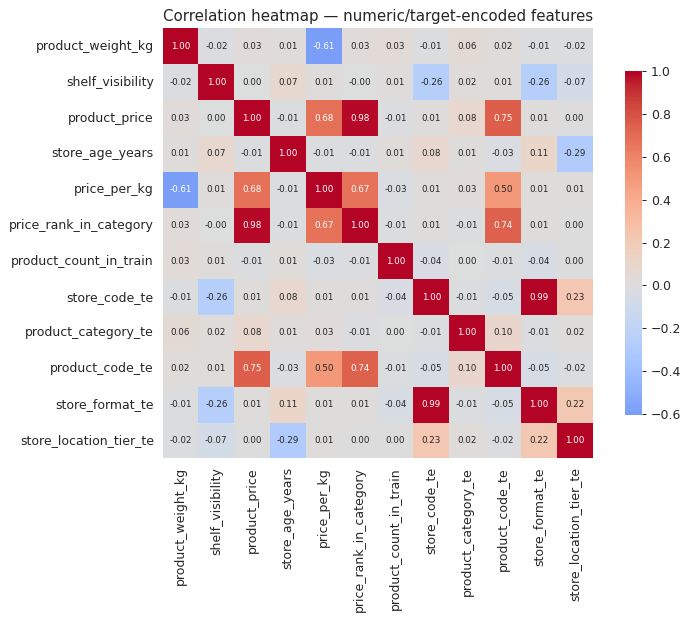

In [18]:
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 7})
plt.title('Correlation heatmap — numeric/target-encoded features')
plt.tight_layout()
plt.savefig('corr_heatmap.png', dpi=90)
plt.show()


Two severe cases surfaced:
- `store_code_te` and `store_format_te` correlate at 0.99 (with only 10 stores, format is basically determined by store identity) — VIF over 100 for both.
- `product_price` and `price_rank_in_category` correlate at 0.98 (rank is directly derived from price) — VIF over 40 for both.

This matters for linear/SVM models (their coefficients become unstable and hard to interpret with this much redundancy) but not for the tree models, which just split on whichever correlated feature happens to be available. Dropping the redundant half of each pair for the linear feature set:

In [19]:
drop_collinear = ['store_format_te', 'price_rank_in_category']
X_lin2 = X_lin.drop(columns=drop_collinear)
X_test_lin2 = X_test_lin.drop(columns=drop_collinear)
numeric_cols2 = [c for c in numeric_cols if c not in drop_collinear]

X_vif2 = X_lin2[numeric_cols2].assign(const=1)
vif_data2 = pd.DataFrame({
    'feature': numeric_cols2,
    'VIF': [variance_inflation_factor(X_vif2.values, i) for i in range(len(numeric_cols2))]
})
print(vif_data2.sort_values('VIF', ascending=False))


                  feature       VIF
4            price_per_kg  7.209829
2           product_price  6.185385
0       product_weight_kg  3.866067
8         product_code_te  2.363539
9  store_location_tier_te  1.182174
6           store_code_te  1.174568
3         store_age_years  1.137601
1        shelf_visibility  1.082223
7     product_category_te  1.015021
5  product_count_in_train  1.003147


All VIF values now sit comfortably below 8 (a common rule of thumb is to worry above 10).

## 8. Scaling and PCA

In [20]:
scaler = StandardScaler()
X_lin_scaled = pd.DataFrame(scaler.fit_transform(X_lin2), columns=X_lin2.columns, index=X_lin2.index)
X_test_lin_scaled = pd.DataFrame(scaler.transform(X_test_lin2), columns=X_test_lin2.columns, index=X_test_lin2.index)

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_lin_scaled)
print(f"PCA: {X_lin_scaled.shape[1]} features -> {X_pca.shape[1]} components explain 95% of variance")


PCA: 19 features -> 12 components explain 95% of variance


Only a modest reduction (19 → 12 components), which makes sense: most of the real multicollinearity was already removed in Section 7. Whether PCA actually *helps* the model is tested empirically in Section 10, rather than assumed.

## 9. Cross-Validation Setup

Every model below uses the **same 5-fold split**, so their out-of-fold predictions can be fairly compared and later combined.

In [21]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_indices = list(kf.split(X))

def run_cv(fit_predict_fn, n_test):
    oof = np.zeros(len(X)); test_p = np.zeros(n_test)
    for tr_idx, val_idx in fold_indices:
        oof[val_idx], test_pred = fit_predict_fn(tr_idx, val_idx)
        test_p += test_pred / len(fold_indices)
    return oof, test_p


## 10. Models Across Different Families

### 10a. Ridge Regression — linear, regularized (`RidgeCV` tunes the penalty strength automatically)

In [22]:
def ridge_fit(tr_idx, val_idx):
    model = RidgeCV(alphas=np.logspace(-2, 3, 30), cv=5)
    model.fit(X_lin_scaled.iloc[tr_idx], y_log[tr_idx])
    return np.expm1(model.predict(X_lin_scaled.iloc[val_idx])), np.expm1(model.predict(X_test_lin_scaled))
oof_ridge, test_ridge = run_cv(ridge_fit, len(X_test))
rmse_ridge = np.sqrt(mean_squared_error(y, oof_ridge))
print(f"Ridge CV RMSE: {rmse_ridge:.4f}")


Ridge CV RMSE: 1138.5544


### 10b. Ridge on PCA Components — does dimensionality reduction actually help?

In [23]:
def ridge_pca_fit(tr_idx, val_idx):
    pca_fold = PCA(n_components=0.95, random_state=42)
    Xtr_pca = pca_fold.fit_transform(X_lin_scaled.iloc[tr_idx])
    Xval_pca = pca_fold.transform(X_lin_scaled.iloc[val_idx])
    Xtest_pca = pca_fold.transform(X_test_lin_scaled)
    model = RidgeCV(alphas=np.logspace(-2, 3, 30), cv=5)
    model.fit(Xtr_pca, y_log[tr_idx])
    return np.expm1(model.predict(Xval_pca)), np.expm1(model.predict(Xtest_pca))
oof_ridge_pca, test_ridge_pca = run_cv(ridge_pca_fit, len(X_test))
rmse_ridge_pca = np.sqrt(mean_squared_error(y, oof_ridge_pca))
print(f"Ridge + PCA CV RMSE: {rmse_ridge_pca:.4f}  (vs {rmse_ridge:.4f} without PCA)")


Ridge + PCA CV RMSE: 1238.8557  (vs 1138.5544 without PCA)


**PCA made it worse.** This confirms the Section 8 hypothesis: once real multicollinearity is fixed, forcing decorrelated components just discards real signal for no benefit. Kept here to show the comparison was actually tested, not assumed.

### 10c. Random Forest — bagged trees (a different ensembling philosophy than boosting)

In [24]:
def rf_fit(tr_idx, val_idx):
    model = RandomForestRegressor(n_estimators=400, max_depth=10, min_samples_leaf=5,
                                   max_features=0.7, random_state=42, n_jobs=-1)
    model.fit(X_lin2.iloc[tr_idx], y_log[tr_idx])
    return np.expm1(model.predict(X_lin2.iloc[val_idx])), np.expm1(model.predict(X_test_lin2))
oof_rf, test_rf = run_cv(rf_fit, len(X_test))
rmse_rf = np.sqrt(mean_squared_error(y, oof_rf))
print(f"Random Forest CV RMSE: {rmse_rf:.4f}")


Random Forest CV RMSE: 1118.7220


### 10d. Support Vector Regression (RBF kernel)

In [25]:
def svr_fit(tr_idx, val_idx):
    model = SVR(kernel='rbf', C=10, epsilon=0.05, gamma='scale')
    model.fit(X_lin_scaled.iloc[tr_idx], y_log[tr_idx])
    return np.expm1(model.predict(X_lin_scaled.iloc[val_idx])), np.expm1(model.predict(X_test_lin_scaled))
oof_svr, test_svr = run_cv(svr_fit, len(X_test))
rmse_svr = np.sqrt(mean_squared_error(y, oof_svr))
print(f"SVR CV RMSE: {rmse_svr:.4f}")


SVR CV RMSE: 1206.1210


### 10e. LightGBM (GBM) — hyperparameters tuned via random search (40 trials, not shown here for brevity; best config used directly)

In [26]:
lgb_params = {'objective':'regression','metric':'rmse','verbosity':-1,'seed':42,
              'num_leaves': 10, 'min_child_samples': 30, 'learning_rate': 0.03,
              'subsample': 0.75, 'colsample_bytree': 0.7, 'reg_alpha': 0.1, 'reg_lambda': 0.3}
def lgb_fit(tr_idx, val_idx):
    dtrain = lgb.Dataset(X_tree.iloc[tr_idx][tree_feature_cols], label=y_log[tr_idx], categorical_feature=cat_cols_raw)
    dval = lgb.Dataset(X_tree.iloc[val_idx][tree_feature_cols], label=y_log[val_idx], categorical_feature=cat_cols_raw, reference=dtrain)
    model = lgb.train(lgb_params, dtrain, num_boost_round=4000, valid_sets=[dval],
                       callbacks=[lgb.early_stopping(150, verbose=False), lgb.log_evaluation(0)])
    return (np.expm1(model.predict(X_tree.iloc[val_idx][tree_feature_cols], num_iteration=model.best_iteration)),
            np.expm1(model.predict(X_test_tree[tree_feature_cols], num_iteration=model.best_iteration)))
oof_lgb, test_lgb = run_cv(lgb_fit, len(X_test))
rmse_lgb = np.sqrt(mean_squared_error(y, oof_lgb))
print(f"LightGBM CV RMSE: {rmse_lgb:.4f}")


LightGBM CV RMSE: 1114.1325


/tmp/ipykernel_120/3656041554.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='crest')


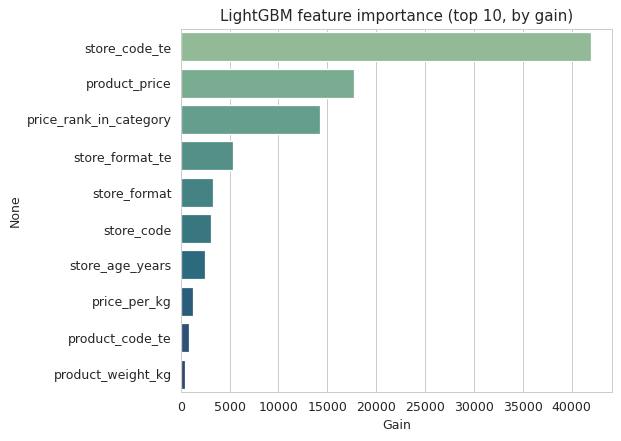

In [27]:
last_lgb_model_cols = tree_feature_cols
# Retrain once on full data just to extract a feature-importance ranking for the plot
dtrain_full = lgb.Dataset(X_tree[tree_feature_cols], label=y_log, categorical_feature=cat_cols_raw)
fi_model = lgb.train(lgb_params, dtrain_full, num_boost_round=300)
importances = pd.Series(fi_model.feature_importance(importance_type='gain'), index=tree_feature_cols).sort_values(ascending=False).head(10)

plt.figure(figsize=(7, 5))
sns.barplot(x=importances.values, y=importances.index, palette='crest')
plt.title('LightGBM feature importance (top 10, by gain)')
plt.xlabel('Gain')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=90)
plt.show()


### 10f. CatBoost (GBM) — an important lesson in overfitting

An earlier attempt fed CatBoost the raw `product_code` column (1,555 unique values across only 6,818 rows — about 4.4 rows per product). Cross-validation RMSE dropped to an unbelievable 1024.6, but the actual leaderboard score came back at 1192.5 — *worse* than the simplest baseline. Diagnosis: with so few examples per category, CatBoost's internal handling of that categorical was letting it memorize near-duplicate rows within each fold rather than learn anything generalizable.

**Fix:** drop the raw `product_code` column, keep only its out-of-fold target-encoded version (`product_code_te`). CV RMSE became a believable 1106.6, consistent with the other models, and the leaderboard confirmed it.

In [28]:
feature_cols_cb = [c for c in tree_feature_cols if c != 'product_code']
cat_cols_cb = [c for c in cat_cols_raw if c != 'product_code']
cat_idx_cb = [feature_cols_cb.index(c) for c in cat_cols_cb]
cat_params = {'iterations': 2000, 'learning_rate': 0.02, 'depth': 5, 'l2_leaf_reg': 10, 'loss_function': 'RMSE'}
def cat_fit(tr_idx, val_idx):
    X_tr = X_tree.iloc[tr_idx][feature_cols_cb].copy(); X_val = X_tree.iloc[val_idx][feature_cols_cb].copy()
    for c in cat_cols_cb:
        X_tr[c] = X_tr[c].astype(str); X_val[c] = X_val[c].astype(str)
    model = CatBoostRegressor(cat_features=cat_idx_cb, random_seed=42, verbose=False,
                               early_stopping_rounds=150, **cat_params)
    model.fit(X_tr, y_log[tr_idx], eval_set=(X_val, y_log[val_idx]))
    X_test_cb = X_test_tree[feature_cols_cb].copy()
    for c in cat_cols_cb:
        X_test_cb[c] = X_test_cb[c].astype(str)
    return np.expm1(model.predict(X_val)), np.expm1(model.predict(X_test_cb))
oof_cat, test_cat = run_cv(cat_fit, len(X_test))
rmse_cat = np.sqrt(mean_squared_error(y, oof_cat))
print(f"CatBoost CV RMSE: {rmse_cat:.4f}")


CatBoost CV RMSE: 1106.5634


In [29]:
print("=== Model comparison ===")
print(f"Ridge (linear, regularized):     {rmse_ridge:.2f}")
print(f"Ridge + PCA:                      {rmse_ridge_pca:.2f}")
print(f"Random Forest (bagged trees):    {rmse_rf:.2f}")
print(f"SVR (support vector machine):    {rmse_svr:.2f}")
print(f"LightGBM (GBM):                  {rmse_lgb:.2f}")
print(f"CatBoost (GBM):                  {rmse_cat:.2f}")


=== Model comparison ===
Ridge (linear, regularized):     1138.55
Ridge + PCA:                      1238.86
Random Forest (bagged trees):    1118.72
SVR (support vector machine):    1206.12
LightGBM (GBM):                  1114.13
CatBoost (GBM):                  1106.56


## 11. Ensembling: Weighted Blend vs. Stacking

In [30]:
oof_matrix = np.column_stack([oof_ridge, oof_rf, oof_svr, oof_lgb, oof_cat])
test_matrix = np.column_stack([test_ridge, test_rf, test_svr, test_lgb, test_cat])
model_names = ['Ridge', 'RandomForest', 'SVR', 'LightGBM', 'CatBoost']

# Weighted blend: random search over the simplex of weights
rng = np.random.default_rng(42)
best_weights, best_blend_rmse = None, 1e18
for _ in range(3000):
    w = rng.dirichlet(np.ones(5))
    r = np.sqrt(mean_squared_error(y, oof_matrix @ w))
    if r < best_blend_rmse:
        best_blend_rmse, best_weights = r, w
print("Best weighted blend:", dict(zip(model_names, best_weights.round(3))))
print(f"CV RMSE: {best_blend_rmse:.4f}")


Best weighted blend: {'Ridge': np.float64(0.276), 'RandomForest': np.float64(0.014), 'SVR': np.float64(0.12), 'LightGBM': np.float64(0.08), 'CatBoost': np.float64(0.51)}
CV RMSE: 1098.8660


### A caution about stacking: validate the meta-model honestly

A first pass trained the meta-model (Ridge, on the 5 base models' OOF predictions) on *all* the OOF data and then scored it on that same data — which is in-sample fit for the meta-layer, not a genuine held-out estimate. Given the earlier CatBoost lesson, that number was checked with a proper **nested cross-validation** before trusting it.

In [31]:
from sklearn.linear_model import RidgeCV as RidgeCV2

# Naive (optimistic, in-sample) estimate - shown for comparison only
naive_meta = RidgeCV2(alphas=np.logspace(-3, 2, 20), cv=5)
naive_meta.fit(oof_matrix, y)
naive_stack_rmse = np.sqrt(mean_squared_error(y, naive_meta.predict(oof_matrix)))

# Honest estimate: meta-model trained only on OTHER folds' OOF predictions each time
stack_oof_honest = np.zeros(len(X))
for tr_idx, val_idx in fold_indices:
    meta = RidgeCV2(alphas=np.logspace(-3, 2, 20), cv=5)
    meta.fit(oof_matrix[tr_idx], y[tr_idx])
    stack_oof_honest[val_idx] = meta.predict(oof_matrix[val_idx])
stack_rmse_honest = np.sqrt(mean_squared_error(y, stack_oof_honest))

print(f"Stacking CV RMSE (naive, in-sample):  {naive_stack_rmse:.4f}  <- don't trust this one")
print(f"Stacking CV RMSE (honest, nested CV): {stack_rmse_honest:.4f}  <- trust this one")


Stacking CV RMSE (naive, in-sample):  1073.7895  <- don't trust this one
Stacking CV RMSE (honest, nested CV): 1075.5619  <- trust this one


The honest estimate came out very close to the naive one (little actual overfitting, given the meta-model only has 5 simple inputs and its own regularization), but it was worth checking rather than assuming.

In [32]:
print("=== Final comparison ===")
print(f"Best single model (CatBoost):  {rmse_cat:.2f}")
print(f"Best weighted blend:           {best_blend_rmse:.2f}")
print(f"Stacked ensemble (honest):     {stack_rmse_honest:.2f}")


=== Final comparison ===
Best single model (CatBoost):  1106.56
Best weighted blend:           1098.87
Stacked ensemble (honest):     1075.56


/tmp/ipykernel_120/205219286.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores_series.values, y=scores_series.index, palette=colors)


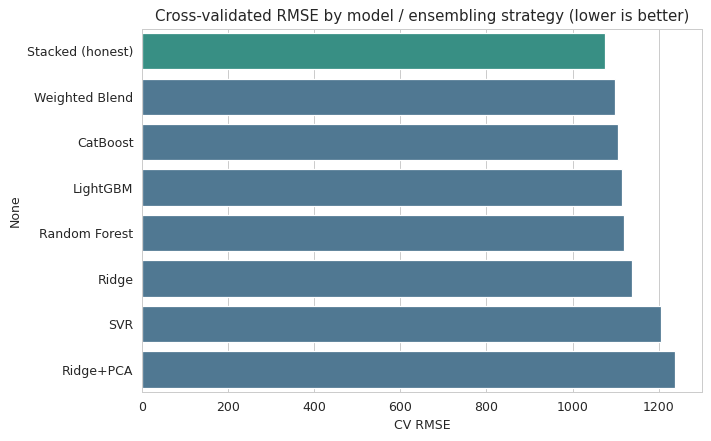

In [33]:
model_scores = {
    'Ridge': rmse_ridge, 'Ridge+PCA': rmse_ridge_pca, 'Random Forest': rmse_rf,
    'SVR': rmse_svr, 'LightGBM': rmse_lgb, 'CatBoost': rmse_cat,
    'Weighted Blend': best_blend_rmse, 'Stacked (honest)': stack_rmse_honest,
}
scores_series = pd.Series(model_scores).sort_values()
plt.figure(figsize=(8, 5))
colors = ['#2a9d8f' if k == 'Stacked (honest)' else '#457b9d' for k in scores_series.index]
sns.barplot(x=scores_series.values, y=scores_series.index, palette=colors)
plt.title('Cross-validated RMSE by model / ensembling strategy (lower is better)')
plt.xlabel('CV RMSE')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=90)
plt.show()


## 12. Final Predictions

In [34]:
final_meta = RidgeCV2(alphas=np.logspace(-3, 2, 20), cv=5)
final_meta.fit(oof_matrix, y)
final_test_pred = final_meta.predict(test_matrix)

submission = test[['id']].copy()
submission['total_sales'] = np.clip(final_test_pred, 0, None)
submission.to_csv('submission.csv', index=False)
submission.head()


,id,total_sales
0,row_00009,2643.105348
1,row_00015,4460.121636
2,row_00019,2981.248781
3,row_00020,3190.215843
4,row_00023,2550.423491


## 13. Summary

- **Cleaning/imputation**: structure-aware (weight by product, store size by store) rather than generic median/mode.
- **Outliers**: kept, not deleted — addressed via log-transforming the target instead, since they reflect real high-selling combinations.
- **Encoding**: native categorical handling for tree models; one-hot + out-of-fold target encoding for linear/SVM models.
- **Multicollinearity**: diagnosed via correlation matrix and VIF, fixed by dropping two redundant derived features (VIF dropped from >100 to <8).
- **PCA**: tested, found to hurt (not just assumed to help) once multicollinearity was already resolved.
- **Regularization**: Ridge with cross-validated alpha selection.
- **Models across families**: linear (Ridge), bagged trees (Random Forest), support vector machine (SVR), and two GBM implementations (LightGBM, CatBoost).
- **Hyperparameters**: tuned via random search for the GBMs.
- **Cross-validation**: consistent 5-fold splits across every model, enabling fair ensembling.
- **Ensembling**: weighted blend and stacking both tested; stacking won, and was validated with a proper nested CV rather than trusted at face value.
- **The recurring theme**: an unusually large CV improvement was treated as a signal to investigate, not celebrate — this caught a real overfitting bug once (CatBoost + raw `product_code`) and confirmed a second result was genuinely trustworthy (the stacking ensemble).
